Tracking classes- BOOSTING,MIL,KCF,CRST,TLD,MEDIANFLOW,GOTURN,MOOSE

In [1]:
#importing library

import cv2
import sys
import os
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
#%matplotlib_inline
from IPython.display import HTML

source="car_racing.mp4"  # source =0 for webcam
def drawRectangle(frame,bbox):
    p1=(int(bbox[0]),int(bbox[1]))
    p2=(int(bbox[0]+ bbox[2]), int(bbox[1]+bbox[3]))
    cv2.rectangle(frame,p1,p2,(255,0,0),2,1)
    
def displayRectangle(frame,bbox):
    plt.figure(figsize=(20,10))
    frameCopy=frame.copy()
    drawRectangle(frameCopy,bbox)
    frameCopy=cv2.cvtColor(frameCopy,cv2.COLOR_RGB2BGR)
    plt.imshow(frameCopy);plt.axis("off")
def drawtext(frame,txt,loaction ,color=(50,170,50)):
    cv2.putText(frame,txt,location,cv2.FONT_HERSHEY_SIMPLEX,1,color,3)

In [2]:
# #download tracking model
# if not os.path.isfile("goturn.prototxt") or not os.path.isfile("goturn.caffemodel"):
#     print("Downloading Doturn model zip file")
#     urlib.request.urlretrieve()

In [3]:
#tracker
tracker_types=['BOOSTING','NIL','KCP','CSRT','TLD','MEDIANFLOW','GOTURN','MOSSE']

tracker_type=tracker_types[2]

tracker_type =='GOTURN'
tracker=cv2.TrackerGOTURN_create()

Read input video and setup output video

In [4]:
video=cv2.VideoCapture(source)
ok, frame=video.read()

if not video.isOpened():
    print("could not open video")
    sys.exit()
else:
    width =int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height=int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
video_output_file_name="race_car" + tracker_type+".mp4"
video_out=cv2.VideoWriter(video_output_file_name,cv2.VideoWriter_fourcc(*'avcl'),10,(width,height))

DEfine BOunding Boux

In [5]:


# 1. Read just the first frame of the video
video_source = "car_racing.mp4"
video = cv2.VideoCapture(video_source)
ret, frame = video.read()
video.release() # We release it immediately after getting the first frame

if ret:
    print("An external window has opened!")
    print("👉 Drag a box over the car, then press ENTER or SPACE.")
    
    # 2. Open the UI to draw the bounding box
    bbox = cv2.selectROI("Select Bounding Box", frame, False)
    cv2.destroyAllWindows()
    
    # 3. Print out the exact coordinates grabbed from the UI
    if bbox != (0, 0, 0, 0):
        print(f"\n✅ Bounding Box successfully captured!")
        print(f"Raw Coordinate Tuple: {bbox}")
        print(f"X (Left): {bbox[0]}")
        print(f"Y (Top):  {bbox[1]}")
        print(f"Width:    {bbox[2]}")
        print(f"Height:   {bbox[3]}")
    else:
        print("\n❌ No bounding box was selected.")
else:
    print("Failed to read the video file.")


An external window has opened!
👉 Drag a box over the car, then press ENTER or SPACE.

✅ Bounding Box successfully captured!
Raw Coordinate Tuple: (224, 260, 237, 152)
X (Left): 224
Y (Top):  260
Width:    237
Height:   152


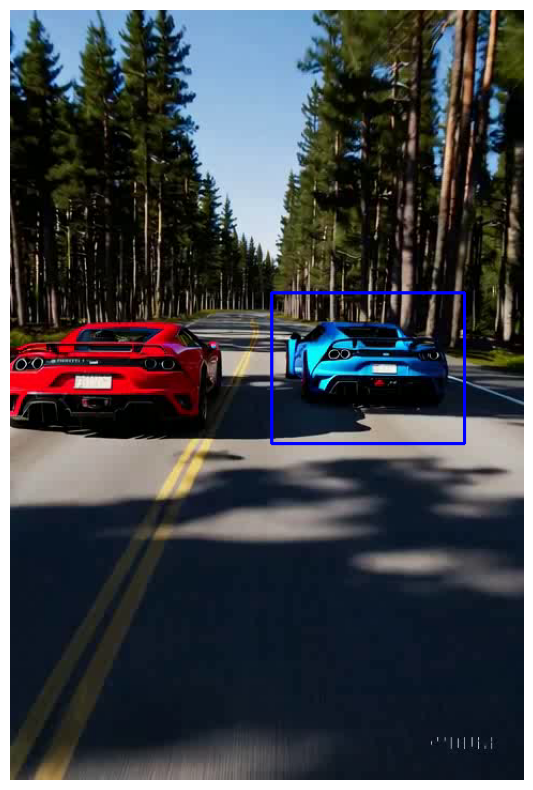

In [6]:
bbox=(244,264,180,141)

displayRectangle(frame,bbox)

INITIALIZE Tracker

In [7]:
ok=tracker.init(frame,bbox)

read fraems

In [8]:
while True:
    ok,frame=video.read()
    if not ok:
        break

    #start timer
    timer=cv2.getTickCount()

    #Update tracker
    ok,bbox=tracker.update(frame)

    #calculate fps
    fps=cv2.getTickFrequency()/(cv2.getTickCount()-timer)
    
    #bounnding box
    if ok:
        drawRectangle(frame,bbox)
    else:
        drawtext(frame,"Tracking failure detected",(100,80),(0,0,255))
        
    #display tracker type on frame
    drawtext(frame,tracker_type+" Tracker",(100,20),(50,170,50))
    drawtext(frame,"FPS:"+str(int(fps)),(100,50),(50,170,50))
    
    video_out.write(frame)
    cv2.imshow("Tracking",frame)
    k=cv2.waitKey(1) & 0xff
video.release()
video_out.release()
cv2.destroyAllWindows()


In [11]:
from IPython.display import HTML
HTML("""<video width="640" height="480" controls>
  <source src="car_racing.mp4" type="video/mp4">
</video>""")